# Chapter 2 experiment harness

Reproduces Table 2.1 and Figure 2.13 of chapter 2.

The comparison is between the two methods the chapter builds, computing the same
item-item model:

| | cuts | worker receives | worker returns | coordinator |
|---|---|---|---|---|
| **Blocked matmul** (2.2) | the output | item columns of `R` for two blocks, all users | one exact tile | assembles |
| **DeMM** (2.3) | the contraction | its own users only | thin factors | sums |

Bytes are counted in **both directions**, because they tell different halves of the
story. Blocked has to broadcast each item block to every worker in its grid row and
again down its column; DeMM sends each user's records to exactly one worker.

Nothing is reimplemented here. Every cell calls the chapter's own modules, so the
notebook cannot drift from the book.

## Environment

In [1]:
import numpy as np

import blocked_matmul_coordinator as blocked
import demm_gram_coordinator as demm_gram
import matmul_launcher
import movielens

# Fast default. Set DATASET = "ml-25m" and TOP_ITEMS = 4000 for the configuration
# the book reports. That downloads about 250 MB once and takes a few minutes.
DATASET, TOP_ITEMS = "ml-latest-small", None
# DATASET, TOP_ITEMS = "ml-25m", 4000

N_WORKERS = 8
RANKS = [16, 32, 64]
USER_SAMPLE = 4000      # score a sample; ml-25m has 162k users
MB = 1e6

print("CUDA kernel path live:", matmul_launcher.gpu_available())
print("evidence class       : simulated_decentralized")
print("  the arithmetic is real; the wide-area network is a byte accounting")

CUDA kernel path live: True
evidence class       : simulated_decentralized
  the arithmetic is real; the wide-area network is a byte accounting


## 2.4 The project

Users are the dimension the model contracts over. A fifth of each user's history is
held out, so quality is measured on interactions the model never saw.

In [2]:
R, titles, info = movielens.load(DATASET, top_items=TOP_ITEMS, holdout=0.2, seed=0)
n_users, n_items = R.shape
grid = blocked.choose_worker_grid(N_WORKERS, n_items, n_items)
raw = info["n_interactions"] * 2 * 4      # R as a coordinate list

print(f"{info['dataset']}: {n_users:,} users x {n_items:,} items, "
      f"{info['n_interactions']:,} training interactions")
print(f"{N_WORKERS} workers: blocked arranges them {grid[0]} x {grid[1]} over the "
      f"model; DeMM gives each one a block of users")

ml-latest-small: 610 users x 1,297 items, 54,318 training interactions
8 workers: blocked arranges them 2 x 4 over the model; DeMM gives each one a block of users


## 2.4.1 Blocked Gram

Each worker owns one tile and returns it exactly. The tiles are disjoint, so what
comes back is one copy of the model at any worker count. What goes out is not: each
item block is needed by every worker in its grid row and again in its grid column.

In [3]:
G_blocked = blocked.blocked_gram(R, device_ids=[0] * N_WORKERS)
bl = blocked.gram_bytes(n_items, info["n_interactions"], N_WORKERS)

G_ref = (R.T @ R).astype(np.float32)      # the centralized product, for comparison
print(f"assembled model                : {G_blocked.shape}")
print(f"matches centralized R^T R to   : {np.abs(G_blocked - G_ref).max():.2e}")
print(f"bytes out  (operand broadcast) : {bl['outbound']/MB:>9,.2f} MB   "
      f"= {bl['outbound']/raw:.0f} copies of the dataset")
print(f"bytes back (disjoint tiles)    : {bl['inbound']/MB:>9,.2f} MB   "
      f"= exactly one copy of the model")

assembled model                : (1297, 1297)
matches centralized R^T R to   : 0.00e+00
bytes out  (operand broadcast) :      2.61 MB   = 6 copies of the dataset
bytes back (disjoint tiles)    :      6.73 MB   = exactly one copy of the model


## 2.4.1 DeMM Gram

The same model, computed by cutting the contraction instead. Two properties of this
particular product are used here, and both belong to the recommender rather than to
DeMM: `G` is symmetric, so only one factor is sent, and the exact item-count diagonal
is carried separately because scoring uses it as a cosine normalizer.

In [4]:
models = {q: demm_gram.demm_gram(R, device_ids=[0] * N_WORKERS, q=q) for q in RANKS}

for q in RANKS:
    back = demm_gram.inbound_bytes(n_items, q, N_WORKERS)
    print(f"q = {q:3}: {N_WORKERS} factors of ({n_items}, {q}) + exact diagonal"
          f"  ->  out {raw/MB:6.2f} MB, back {back/MB:6.2f} MB")

q =  16: 8 factors of (1297, 16) + exact diagonal  ->  out   0.43 MB, back   0.71 MB
q =  32: 8 factors of (1297, 32) + exact diagonal  ->  out   0.43 MB, back   1.37 MB
q =  64: 8 factors of (1297, 64) + exact diagonal  ->  out   0.43 MB, back   2.70 MB


## Table 2.1

Actuals first, then the ratios the book reports. The byte figures are deterministic:
they follow from the catalogue size, the rank and the worker count, so you should get
them exactly. Quality depends on the hold-out split and the random probe, so expect
the last digit to move.

The **ratios** here are dataset-dependent too, because they compare the size of the
model against the size of the raw data, and those scale differently. The book's
figures come from `ml-25m`; the small dataset shows the same shape at smaller
multiples.

In [5]:
def recall_at_50(score):
    """Held-out recall@50, averaged over the users who had a hold-out at all."""
    rel = info["relevant"]
    eligible = [u for u in range(n_users) if rel[u]]
    if USER_SAMPLE and len(eligible) > USER_SAMPLE:      # ml-25m has 162k users
        eligible = np.random.default_rng(0).choice(
            np.array(eligible), size=USER_SAMPLE, replace=False).tolist()
    hits, seen = 0.0, 0
    for u in eligible:
        liked = np.flatnonzero(R[u])
        if liked.size == 0:
            continue
        top, _ = score(liked)
        hits += len(rel[u] & set(int(i) for i in top)) / len(rel[u])
        seen += 1
    return hits / seen if seen else 0.0


base = recall_at_50(lambda liked: blocked.recommend(G_blocked, liked, top_n=50))
rows = [("Blocked Gram, exact tiles", bl["outbound"], bl["inbound"], base)]
for q in RANKS:
    r = recall_at_50(lambda liked, q=q: demm_gram.recommend(models[q], liked, top_n=50))
    rows.append((f"DeMM Gram, rank {q}", raw,
                 demm_gram.inbound_bytes(n_items, q, N_WORKERS), r))

print("ACTUALS on this machine and this split")
print(f"{'Method':30}{'out MB':>9}{'back MB':>9}{'total MB':>10}{'recall@50':>11}")
for name, out, back, rec in rows:
    print(f"{name:30}{out/MB:9.2f}{back/MB:9.2f}{(out + back)/MB:10.2f}{rec:11.4f}")

b_out, b_back = rows[0][1], rows[0][2]
b_tot = b_out + b_back
print()
print("RATIOS  (this is what Table 2.1 in the book reports)")
print(f"{'Method':30}{'bytes out':>12}{'bytes back':>12}{'total':>10}{'quality':>10}")
for name, out, back, rec in rows:
    print(f"{name:30}{b_out/out:11.1f}x{b_back/back:11.1f}x"
          f"{b_tot/(out + back):9.1f}x{100 * rec / base:9.0f}%")

print()
print("DeMM wins both directions, for different reasons. Going out, blocked")
print("broadcasts each item block across its grid row and column while DeMM sends")
print("each user's records once. Coming back, blocked returns one copy of the model")
print("and DeMM returns a description of each partial product instead.")

ACTUALS on this machine and this split
Method                           out MB  back MB  total MB  recall@50
Blocked Gram, exact tiles          2.61     6.73      9.34     0.3892
DeMM Gram, rank 16                 0.43     0.71      1.14     0.3615
DeMM Gram, rank 32                 0.43     1.37      1.80     0.3852
DeMM Gram, rank 64                 0.43     2.70      3.13     0.3900

RATIOS  (this is what Table 2.1 in the book reports)
Method                           bytes out  bytes back     total   quality
Blocked Gram, exact tiles             1.0x        1.0x      1.0x      100%
DeMM Gram, rank 16                    6.0x        9.5x      8.2x       93%
DeMM Gram, rank 32                    6.0x        4.9x      5.2x       99%
DeMM Gram, rank 64                    6.0x        2.5x      3.0x      100%

DeMM wins both directions, for different reasons. Going out, blocked
broadcasts each item block across its grid row and column while DeMM sends
each user's records once. Coming back

## The exact normalizer

Section 2.4.1 says the item-count diagonal has to be carried exactly rather than
approximated along with everything else. This is the measurement behind that claim,
and it runs against the grain of the rest of the chapter: the penalty for dropping it
**grows** as the rank rises.


The book's figures for this cell come from `ml-25m`.

In [6]:
print(f"{'rank':>6}{'exact normalizer':>21}{'from the factors':>21}{'cost':>8}")
for q in RANKS:
    m = models[q]
    exact_r = recall_at_50(lambda liked, m=m: demm_gram.recommend(m, liked, top_n=50))

    approx = dict(m)                    # same factors, normalizer taken FROM them
    approx["diag"] = np.clip(
        sum((np.asarray(F) ** 2).sum(axis=1) for F in m["factors"]), 1e-9, None)
    approx_r = recall_at_50(lambda liked, a=approx: demm_gram.recommend(a, liked, top_n=50))

    print(f"{q:6}{exact_r:14.4f} ({100 * exact_r / base:3.0f}%)"
          f"{approx_r:14.4f} ({100 * approx_r / base:3.0f}%)"
          f"{100 * (exact_r - approx_r) / exact_r:7.0f}%")

print()
print("A higher-rank fit reproduces the dominant diagonal more faithfully, and that")
print("diagonal is each item's own interaction count, so a faithful reproduction is")
print("exactly what floods the recommendations with whatever is most popular.")

  rank     exact normalizer     from the factors    cost
    16        0.3615 ( 93%)        0.4095 (105%)    -13%
    32        0.3852 ( 99%)        0.4141 (106%)     -8%


    64        0.3900 (100%)        0.3948 (101%)     -1%

A higher-rank fit reproduces the dominant diagonal more faithfully, and that
diagonal is each item's own interaction count, so a faithful reproduction is
exactly what floods the recommendations with whatever is most popular.


## Figure 2.13

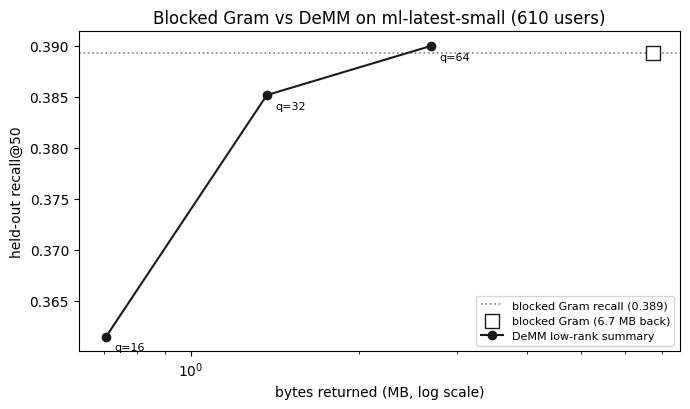

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.0, 4.2))
demm_rows = [r for r in rows if r[0].startswith("DeMM")]
ax.axhline(base, ls=":", color="0.5", lw=1.2, label=f"blocked Gram recall ({base:.3f})")
ax.scatter([rows[0][2] / MB], [base], s=90, marker="s", facecolor="white",
           edgecolor="#1a1a1a", zorder=5,
           label=f"blocked Gram ({rows[0][2] / MB:,.1f} MB back)")
ax.plot([r[2] / MB for r in demm_rows], [r[3] for r in demm_rows], "-o",
        color="#1a1a1a", zorder=4, label="DeMM low-rank summary")
for (name, _o, back, rec), q in zip(demm_rows, RANKS):
    ax.annotate(f"q={q}", (back / MB, rec), textcoords="offset points",
                xytext=(6, -10), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("bytes returned (MB, log scale)")
ax.set_ylabel("held-out recall@50")
ax.set_title(f"Blocked Gram vs DeMM on {info['dataset']} ({n_users:,} users)")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()
plt.show()

## What the harness does not show

**The network.** Workers are threads on one machine. Every byte figure is arithmetic
from the shapes, not a measurement of a link, which is what `simulated_decentralized`
means. Chapter 8 builds the full latency model; here the transfer term is the only one
the byte counts can honestly support.

**Amortization.** The outbound cost is paid when workers are given their data. A
recommender is rebuilt on a schedule from workers that keep their shards between
builds, so in steady state the return path is what an operator pays each time.

**Failure.** Try dropping workers in the app rather than here. The two methods degrade
differently: blocked assembles disjoint tiles, so a missing worker leaves a hole in the
model, while DeMM merges by addition, so a missing worker removes only its own users'
contributions. Chapter 3 is about that asymmetry.